# Исследование рынка общепита Москвы

## Цель и задачи  

**Цель:** Провести исследовательский анализ рынка общепита Москвы. Для инвестиционного фонда. 

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных.
4. Сформулировать выводы по проведённому анализу.


## Данные

Данные с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Данные состоят из двух датасетов:

- `/datasets/rest_info.csv` — содержит информацию о заведениях общественного питания;
- `/datasets/rest_price.csv` —  содержит информацию о среднем чеке в заведениях общественного питания.

### Описание датасета `rest_info.csv`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - `0` — заведение не является сетевым;
    - `1` — заведение является сетевым.
- `seats` — количество посадочных мест.

### Описание датасета `rest_price`

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
    - и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## 1. Загрузка данных и знакомство с ними


---
Начнём с загрузки библиотек и датасетов `rest_info.csv` и `/rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

---

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для рассчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными датасета `info_df.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
info_df.head(10)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0


In [4]:
# Выводим информацию о датафрейме
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим статестические метрики о датафрейме
info_df.describe()

,rating,chain,seats
count,8406.000000,8406.000000,4795.000000
mean,4.229895,0.381275,108.421689
std,0.470348,0.485729,122.833396
min,1.000000,0.000000,0.000000
25%,4.100000,0.000000,40.000000
50%,4.300000,0.000000,75.000000
75%,4.400000,1.000000,140.000000
max,5.000000,1.000000,1288.000000


--------
Датасет `info_df` содержит 9 столбцов и 8405 строк, в которых представлена информация о конкретной заведении общепита.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов впорядке, прописанны по принципу snake case.
- Представленные данные хранят текстовые значения в формате `object` или содержат числовые значения и хранятся в типах данных `int64` или `float64`. Данные в стобце `chain` содержат значения 1 или 0 — размерность этих данных можно оптимизировать.
- Тип данных в столбце `seats` не соответствуют содержимому, меняем на `int16`.
- Пропуски содержатся только в столбцах `hours` и `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

--------

Теперь познакомимся с данными датасета `price_df.csv`.

In [6]:
# Выводим первые строки датафрейма на экран
price_df.head(10)

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN
5,96ebceb1a09e4e3191133b9fe0379a64,средние,Средний счёт:199 ₽,199.0,NaN
6,0243288b78024af090b8e947842c969c,средние,Средний счёт:200–300 ₽,250.0,NaN
7,36aeb0ffa69c48fdb0021549520deb10,средние,Средний счёт:от 500 ₽,500.0,NaN
8,487167877eb04288bc90d4fa80646fc2,средние,Средний счёт:1000–1200 ₽,1100.0,NaN
9,ac32978af97641bfacf996e7f5a50ee5,средние,Цена бокала пива:250–350 ₽,NaN,NaN


In [7]:
# Выводим информацию о датафрейме
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [8]:
# Выводим статестические метрики о датафрейме
price_df.describe()

,middle_avg_bill,middle_coffee_cup
count,3149.000000,535.000000
mean,958.053668,174.721495
std,1009.732845,88.951103
min,0.000000,60.000000
25%,375.000000,124.500000
50%,750.000000,169.000000
75%,1250.000000,225.000000
max,35000.000000,1568.000000



--------
Датасет `price_df.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о ценах в конкретном заведении общепита. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов впорядке, прописанны по принципу snake case.
- Типы данных соответствуют содержимому.
- Пропуски есть в столбцах `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`. Неободимо изучить каждый столбец по отдельности.
- Значения в столбцах соответствуют описанию.

---

## 2. Предобработка данных

### 2.1. Оптимизируем типы данных


---

Данные в стобце `chain` содержат значения 1 или 0 — размерность этих данных будем оптимизировать.

---

In [9]:
# Оптимизируем целочисленный тип данных в датафрейме info_df
info_df['chain'] = pd.to_numeric(info_df['chain'], downcast='integer')

Тип данных в столбце `seats` не соответствуют содержимому, меняем на `int16`.

In [10]:
# Меняем тип данных в столбеце seats на формат int16
info_df['seats'] = info_df['seats'].astype('Int16')

In [11]:
# Проверяемм типы данных в датафрейме info_df с помощью атрибута dtypes
info_df.dtypes

id           object
name         object
category     object
address      object
district     object
hours        object
rating      float64
chain          int8
seats         Int16
dtype: object

---

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

---

### 2.2. Проверяем наличие пропусков в данных



---

При первичном анализе мы обнаружили пропуски в столбцах `hours` и `seats` датафрейма `info_df`. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

---

In [12]:
# Применяем метод isna() к датафрейму info_df
info_df.isna().sum()

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [13]:
# Подсчитываем долю строк с пропусками
info_df.isna().sum() / info_df.shape[0] * 100

id           0.000000
name         0.000000
category     0.000000
address      0.000000
district     0.000000
hours        6.376398
rating       0.000000
chain        0.000000
seats       42.957411
dtype: float64

---

При первичном анализе мы обнаружили пропуски в столбцах `price`, `avg_bill`,`middle_avg_bill`,`middle_coffe_cup` из датафрейма ` price_df`. Узнаем абсолютное и относительное количество пропусков в этих столбцах.

---

In [14]:
# Применяем метод isna() к датафрейму price_df
price_df.isna().sum()

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

In [15]:
# Подсчитываем долю строк с пропусками
price_df.isna().sum() / price_df.shape[0] * 100

id                    0.000000
price                18.309512
avg_bill              5.963529
middle_avg_bill      22.400197
middle_coffee_cup    86.816166
dtype: float64

---

В датафрейме `info_df` обнаружено:
- В столбце `hours` 536 пропусков  — это более 6% данных. Этот столбец необходим нам для дальнейших расчётов. 
- В столбце `seats` обнаружено 3611 пропусков — это более 42% данных. Не факт, что этот столбец нам пригодиться для анализа данных. 

Количество пропусков, в обоих случаях, достаточно большое, чтобы их просто удалить.
Скорее всего, в этих столбцах пропуски MNAR — мы не знаем точной причины отсутсвия данных. Лучше всего заменить пропуски на значение-индикатор `-1`, чтобы не удалять строки, которые могут быть полезны для проведеня анализа.

---

В датафрейме `price_df` обнаружено:
- В столбце `price` 743 пропуска  — это более 18% данных. В нем значения деляться на категории. Этот столбец необходим нам для дальнейших исследований. Мы можем заполнить пропуски в нём исходя из данных столбца `middle_avg_bill`. Если знаение в нём соответсвует среднему значению для конкоретной катеогрии, то заполяем пропуск в оответсвии с ним.
- В столбце `middle_avg_bill` 909 пропусков — это более 22% данных. Мы можем заполнить пропуски в этом столбце средними значениями для каждой из категорий, исходя из значений в столбце `price`.
- В столбце `middle_coffe_cup` 3523 пропусков — это более 86% данных. Не факт, что этот столбец нам пригодиться для анализа данных. Восстановить пропуски в нём не получится.
- В столбце `avg_bill` 242 пропусков — это более 5% данных. Скорее всего, этот столбец нам не пригодиться для анализа данных. Восстановить пропуски в нём не получится.
  
Во всех столбцах из датафрейма `price_df`, в которых остались пропуски пропуски, применяем функцию для замены на значение-индикатор `-1`, чтобы не удалять строки, которые могут быть полезны для проведеня анализа.

---


#### Предобработка пропусков в датафрейме info_df

In [16]:
# Заменяем пропуски в дата фрейме info_df значениями-индикаторами
info_df['hours'] = info_df['hours'].fillna(-1)
info_df['seats'] = info_df['seats'].fillna(-1)

In [17]:
# Проверяем долю строк с пропусками
info_df.isna().sum() / info_df.shape[0] * 100

id          0.0
name        0.0
category    0.0
address     0.0
district    0.0
hours       0.0
rating      0.0
chain       0.0
seats       0.0
dtype: float64

#### Предобработка пропусков в датафрейме price_df


In [24]:
# Пишем функцию для замены пропусков в столбцах датафрейма price_df на значения-индикаторы
columns_to_fill = ['middle_coffee_cup', 'middle_avg_bill', 'avg_bill', 'price']
price_df[columns_to_fill] = price_df[columns_to_fill].fillna(-1)

In [25]:
# Проверяем долю строк с пропусками в столбце price
price_df.isna().sum() / price_df.shape[0] * 100

id                   0.0
price                0.0
avg_bill             0.0
middle_avg_bill      0.0
middle_coffee_cup    0.0
dtype: float64

### 2.3. Явные и неявные дубликаты в данных


---
Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

---

In [26]:
# Проверяем явные дубликаты в датафрейме filled_price_df
price_df.duplicated().sum()

0

In [27]:
# Проверяем явные дубликаты в датафрейме info_df
info_df.duplicated().sum()

0

---------

В датафреймах нет явных дубликатов строк. Проверим неявные дубликаты.

---------

<div class="alert alert-block alert-info">
<b> Проводим нормализацию текста в стоблце name.
    Ищем дубликаты в привязке к адресу и id.
</div>

In [31]:
# Пишем функцию для нормализации текста:

def normalize_text(text):
    # Приведение к нижнему регистру
    text = text.lower()
    # Удаление лишних пробелов
    normalized_text = ' '.join(text.split())
    return normalized_text

# Применяем нормализацию к столбцам name и address
info_df['name'] = info_df['name'].apply(normalize_text)
info_df['address'] = info_df['address'].apply(normalize_text)

# Смотрим результат
print(info_df['name'])
print(info_df['address'])

0                     wowфли
1             четыре комнаты
2                      хазри
3       dormouse coffee shop
4                  иль марко
                ...         
8401              суши мания
8402               миславнес
8403                 самовар
8404            чайхана sabr
8405              kebab time
Name: name, Length: 8406, dtype: object
0                       москва, улица дыбенко, 7/1
1               москва, улица дыбенко, 36, корп. 1
2                   москва, клязьминская улица, 15
3              москва, улица маршала федоренко, 12
4                  москва, правобережная улица, 1б
                           ...                    
8401                 москва, профсоюзная улица, 56
8402    москва, пролетарский проспект, 19, корп. 1
8403        москва, люблинская улица, 112а, стр. 1
8404        москва, люблинская улица, 112а, стр. 1
8405                москва, россошанский проезд, 6
Name: address, Length: 8406, dtype: object


In [32]:
# Проверяем уникальные значения в столбцах и их количество
for column in ['id','name', 'address', 'category', 'district', 'chain']:
    print(f'Уникальные значения в столбце {column}:')
    unique_values = info_df[column].sort_values().unique()
    print(unique_values)
    print(f'Количество уникальных значений: {len(unique_values)}')
    print()

Уникальные значения в столбце id:
['0009f005d6fb47c6b067db5084f4e05a' '000c4f8e2c6b4a8e81127ed094688658'
 '0028eb1543284e18a0acdb0343a66107' ... 'ffda7a385ab34248ba4fddfcb653dbac'
 'ffe1ca40df284b4094b6cf051b45e4ac' 'fffda460734f4981bd2e50c5d766e469']
Количество уникальных значений: 8406

Уникальные значения в столбце name:
['#кешбэккафе' '+39 pizzeria mozzarella bar' '1 этаж' ... 'ё-ланч'
 'ёж и устрица' 'ёрш']
Количество уникальных значений: 5512

Уникальные значения в столбце address:
['москва, 1-й автозаводский проезд, 5'
 'москва, 1-й балтийский переулок, 3/25'
 'москва, 1-й варшавский проезд, 1ас9' ...
 'москва, яузский бульвар, 11, стр. 1' 'москва, яузский бульвар, 14/8'
 'москва, № 7']
Количество уникальных значений: 5752

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']
Количество уникальных значений: 8

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный админи

---

После нормализации текста в столбце name количество уникальных значений сократилось с 5614 до 5512.
В столбце address с 5753 до 5752.

---

In [33]:
# Проверяем неявные дубликаты в датафрейме info_df в связке столбцов name и address
info_df.duplicated(subset=['name', 'address']).sum()

4

In [34]:
# Удаление дубликатов
info_df.drop_duplicates(subset=['name', 'address'], inplace=True)

In [35]:
# Проверяем неявные дубликаты в датафрейме price_df
price_df.duplicated(subset='id').sum()

0

#### Дополнительная предобработка столбца chain

---

Из описания датафремов, мы помним условие о том, что значения в столбце chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки). Ищем маленькие сети с ошибками.

---

In [36]:
# Смотрим изначальные значения столбца
print(info_df['chain'].value_counts())

0    5199
1    3203
Name: chain, dtype: int64


In [37]:
# Значение "1" в столбце chain говорят о том, что заведение сетевое. Следовательно, у сетей должно быть больше одного адреса. По этим параметрам фильтруем.
chain_counts = info_df.groupby(['name']).agg({'address': 'count', 'chain': 'sum'})

# Фильтруем строки, где address == 1 и chain == 1
error_small_chains = chain_counts[(chain_counts['address'] == 1) & (chain_counts['chain'] == 1)]

# Проверяем результат
print(error_small_chains)


                     address  chain
name                               
1-я креветочная            1      1
4 сезона                   1      1
bakery                     1      1
bigсуши                    1      1
drive                      1      1
easy pizza                 1      1
halal food                 1      1
home                       1      1
kimpab                     1      1
ploveberry                 1      1
ricers                     1      1
suшi                       1      1
tasty thai                 1      1
vintage                    1      1
wаурма                     1      1
zafferano                  1      1
бакинский дворик           1      1
баку                       1      1
барбарис                   1      1
бюро пиццы                 1      1
в своей тарелке            1      1
виолино                    1      1
городок                    1      1
дайнинг холл               1      1
дастархан                  1      1
диана                      1

In [38]:
# Получаем список значений, которые нужно изменить
names_to_replace = error_small_chains.index

# Заменяем значения в столбце chain на "0" 
info_df.loc[info_df['name'].isin(names_to_replace) & (info_df['chain'] == 1), 'chain'] = 0

In [39]:
# Проверяем значения столбца
print(info_df['chain'].value_counts())

0    5258
1    3144
Name: chain, dtype: int64


---

Все значения выглядят корректными и полностью готовы для дальнейшего анализа.

---

#### Создаём новый столбец is_24_7

In [40]:
# Функция для проверки работы заведения 24/7
def is_open_24_7(hours):
    if isinstance(hours, str):  # Проверяем, является ли hours строкой
        return 'ежедневно' in hours and 'круглосуточно' in hours
    return False  # Если hours не строка, возвращаем False

# Применяем функцию к столбцу hours
info_df['is_24_7'] = info_df['hours'].apply(is_open_24_7)

# Смотрим результат
print(info_df[['hours', 'is_24_7']])

                                                  hours  is_24_7
0                                ежедневно, 10:00–22:00    False
1                                ежедневно, 10:00–22:00    False
2     пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...    False
3                                ежедневно, 09:00–22:00    False
4                                ежедневно, 10:00–22:00    False
...                                                 ...      ...
8401                             ежедневно, 09:00–02:00    False
8402                             ежедневно, 08:00–22:00    False
8403                           ежедневно, круглосуточно     True
8404                           ежедневно, круглосуточно     True
8405                           ежедневно, круглосуточно     True

[8402 rows x 2 columns]


In [41]:
# Ещё раз проверяем изменения, фильтруем строки, где в hours есть "круглосуточно"
filter_df = info_df[info_df['hours'].astype(str).str.contains('круглосуточно', na=False)]

# Смотрим результат
print(filter_df[['hours', 'is_24_7']])

                         hours  is_24_7
10    ежедневно, круглосуточно     True
17    ежедневно, круглосуточно     True
19    ежедневно, круглосуточно     True
24    ежедневно, круглосуточно     True
49    ежедневно, круглосуточно     True
...                        ...      ...
8394  ежедневно, круглосуточно     True
8399  ежедневно, круглосуточно     True
8403  ежедневно, круглосуточно     True
8404  ежедневно, круглосуточно     True
8405  ежедневно, круглосуточно     True

[772 rows x 2 columns]


### 2.4. Промежуточные выводы после предобработки 

---

В результате предобработки данных были выполнены следующие действия:

- Оптимизировали данные в стобце `chain`.
- Изучены пропуски в данных. В обоих датафреймах заменены на значения индикаторы `-1`.
- Провели нормализацию текста в категориальных столбцах.
- Данные проверили на явные и неявные дубликаты. Были найдёны и удалены неявные дубликаты.
- Отредактировали значения в столбце `chain` в оответствии с пренадлежнастью к сети.
- Создан новый столбец `is_24_7`
---

### 2.5. Подготовка единого датафрейма

---

Задача иследования предполагает изчение рынка общепита Москвы и для анализа нам необходимы полные данные. Поэтому, объединяем датафреймы по `id` используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные о кафе.

---

In [42]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how='outer')

In [43]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8401
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              8402 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int8   
 8   seats              8402 non-null   Int16  
 9   is_24_7            8402 non-null   bool   
 10  price              4058 non-null   object 
 11  avg_bill           4058 non-null   object 
 12  middle_avg_bill    4058 non-null   float64
 13  middle_coffee_cup  4058 non-null   float64
dtypes: Int16(1), bool(1), float64(3), int8(1), object(8)
memory usage: 828.7+ KB


In [44]:
# Визуальный осмотр
df.head()

,id,name,category,address,district,hours,rating,chain,seats,is_24_7,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,-1,False,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,False,выше среднего,Средний счёт:1500–1600 ₽,1550.0,-1.0
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,False,средние,Средний счёт:от 1000 ₽,1000.0,-1.0
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,-1,False,-1,Цена чашки капучино:155–185 ₽,-1.0,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,False,средние,Средний счёт:400–600 ₽,500.0,-1.0


-----

Данные соединены и готовы к дальнейшему анализу.

---

## 3. Исследовательский анализ данных

### 4.1 Анализ категорий заведений.

Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [76]:
# Группируем данные по категории и смотрим количество заведений в каждой из категорий
category_counts = df['category'].value_counts()
# Смотрим результат
print(category_counts)

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64


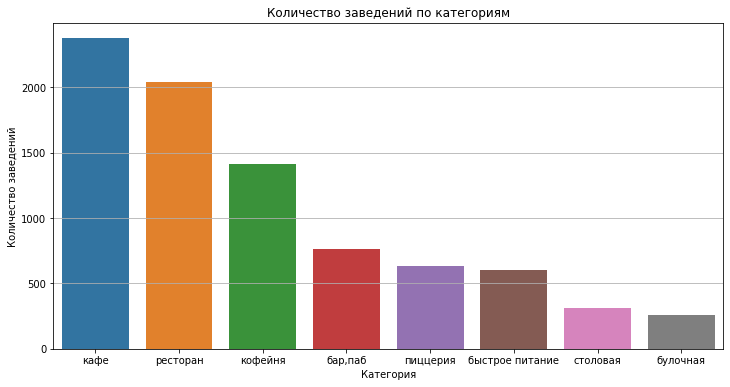

In [77]:
# Создаем столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values)
# Настраиваем график
plt.title('Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.grid(axis='y')

plt.show()

В топ-3 с большим отрывом лидируют категории: кафе - `2376`заведений, ресторан - `2042`заведений и кофейня `1413` заведений.
Меньше всего: столовых - `182` заведений и булочных `54` заведений.

### 4.2 Анализ данных по округам города.

In [78]:
# Группируем данные по округу и смотрим количество заведений в каждой из них
district_counts = df['district'].value_counts()
# Смотрим результат
print(district_counts)

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64


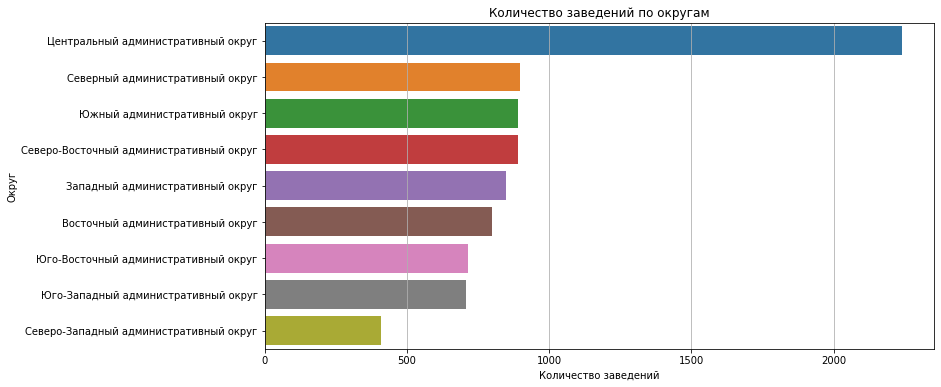

In [79]:
# Создаем горизонтальную столбчатую диаграмму
plt.figure(figsize=(12, 6))
sns.barplot(x=district_counts.values, y=district_counts.index)

# Настраиваем график
plt.title('Количество заведений по округам')
plt.xlabel('Количество заведений')
plt.ylabel('Округ')
plt.grid(axis='x')

# Показываем график
plt.show()

In [80]:
# Отдельно рассмотрим распределение заведений каждой категории в Центральном административном округе
filtered = df[df['district'] == 'Центральный административный округ']

# Группируем отфильтрованные данные по категории и считаем количество
category_cao = filtered['category'].value_counts().sort_values(ascending=False)
# Смотрим результат
print(category_cao)

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64


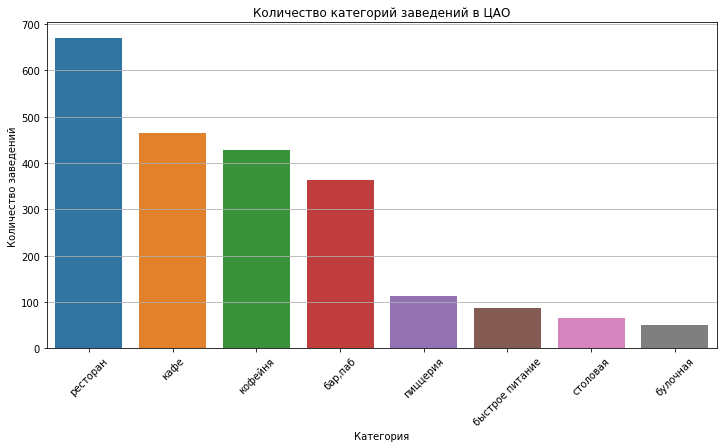

In [81]:
plt.figure(figsize=(12, 6))
sns.barplot(x=category_cao.index, y=category_cao.values)

# Настраиваем график
plt.title('Количество категорий заведений в ЦАО')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Показываем график
plt.show()

Больше всего в ЦАО ресторанов: `670` заведений, кафе: `464` и кофейнь: `428`. Меньше всего столовых и булочных: `44` и `13`.

In [82]:
# Общее количество заведений в Центральном административном округе
total_cao = district_counts['Центральный административный округ']

# Рассчитываем долю для каждой категории
share = category_cao / total_cao

# Смотрим результат
print(share)

ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: category, dtype: float64


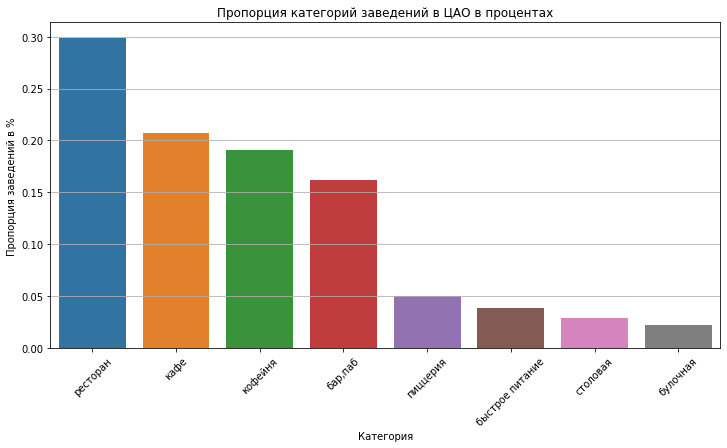

In [83]:
# Визуализируем

plt.figure(figsize=(12, 6))
sns.barplot(x=share.index, y=share.values)

# Настраиваем график
plt.title('Пропорция категорий заведений в ЦАО в процентах')
plt.xlabel('Категория')
plt.ylabel('Пропорция заведений в %')
plt.xticks(rotation=45)
plt.grid(axis='y')

# Показываем график
plt.show()

Практически 30% заведений в ЦАО - это рестораны, чуть более 20%, это кафе. Ниже 5% находяться: пиццерии, быстрое питание, столовые и булочные. Такая пропорция, скорее всего, связана с тем, что у заведений в ЦАО высокая ценовая политика, которая не свойствена заведением категории: пиццерия, быстрое питание, столовыя и булочная.

### 4.3 Анализ соотношение сетевых и несетевых заведений.

In [84]:
# Cмотрим количество сетевых и несетевых заведений
chain_counts = df['chain'].value_counts()
print(chain_counts)

0    5258
1    3144
Name: chain, dtype: int64


Несетевых заведений намного больше, чем сетвых.

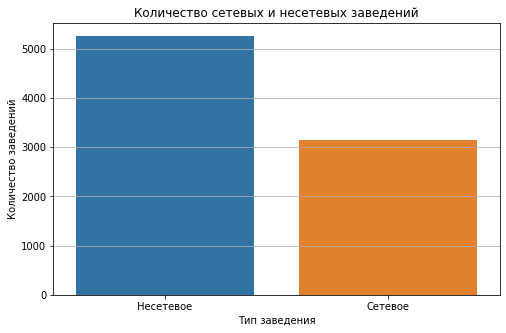

In [85]:
# Визуализация
plt.figure(figsize=(8, 5))
sns.barplot(x=chain_counts.index, y=chain_counts.values)
plt.title('Количество сетевых и несетевых заведений')
plt.xlabel('Тип заведения')
plt.ylabel('Количество заведений')
plt.grid(axis='y')
plt.xticks(ticks=[0, 1], labels=['Несетевое', 'Сетевое'])
plt.show()

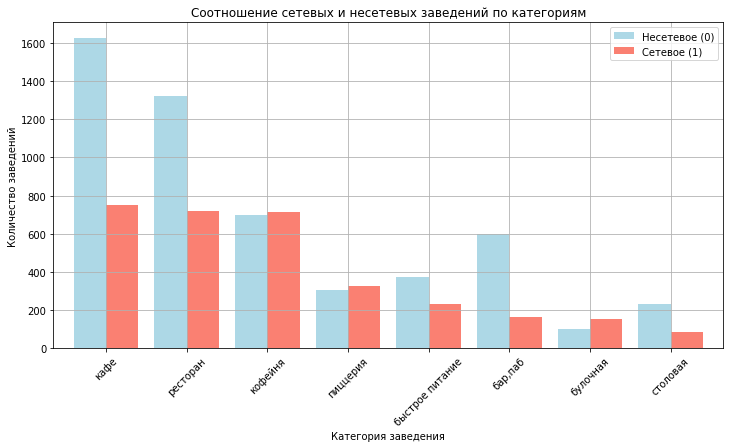

In [86]:
# Группировка по категориям и подсчет сетевых и несетевых заведений
category_chain_counts = df.groupby(['category', 'chain']).size().unstack(fill_value=0).sort_values(by=1, ascending=False)

# Визуализация
category_chain_counts.plot(kind='bar', figsize=(12, 6), color=['lightblue', 'salmon'], width=0.8)
plt.title('Соотношение сетевых и несетевых заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45)
plt.legend(['Несетевое (0)', 'Сетевое (1)'])
plt.grid()
plt.show()

Больше всего сетевых заведений находится в категориях: ресторан, кофейня и кафе.
Несетевых, больше всего: кафе и ресторанов.

### 4.4 Анализ посадочных мест в заведениях. 

In [87]:
# Группируем данные по категории и формируем средние значения посадочных мест для каждой из них
# Фильтруем значения-индикаторы -1 в столбце seats 
filtered_seats = df[df['seats'] != -1]
filtered_seats.groupby('category')['seats'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)

,mean,median,min,max
category,,,,
"бар,паб",124.477516,82.0,0,1288
ресторан,121.892041,86.0,0,1288
кофейня,111.199734,80.0,0,1288
столовая,99.75,75.5,0,1200
быстрое питание,98.891117,65.0,0,1040
кафе,97.365653,60.0,0,1288
пиццерия,94.496487,55.0,0,1288
булочная,89.385135,50.0,0,625


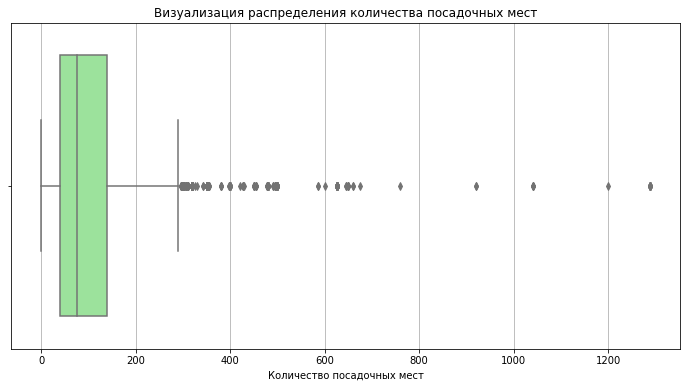

In [88]:
# Визуализируем результат
filtered_seats = df[df['seats'] != -1]

# Визуализация боксплота
plt.figure(figsize=(12, 6))
sns.boxplot(x=filtered_seats['seats'], color='lightgreen')
plt.title('Визуализация распределения количества посадочных мест')
plt.xlabel('Количество посадочных мест')
plt.grid(axis='x')
plt.show()

Мы наблюдаем большую разницу между средним значением и медианной. Следовательно, в данных присутсвует большое количество анамальных значений.
И, именно, медианные значения стоит считать более близкими к правильным данным. Стоит отметить, что большая часть значений посадочных мест находится диапозоне от 40 до 150 мест.

In [89]:
# Посмотрим количество анамальных значений:
count_0_seats = df[df['seats'] == 0].shape[0]
count_many_seats = df[df['seats'] > 650].shape[0]
# Вывод результатов
print(f'Количество заведений с нулевыми посадочными местами: {count_0_seats}')
print(f'Количество заведений с, более чем, шестисот пятидесяти посадочными местами: {count_many_seats}')

Количество заведений с нулевыми посадочными местами: 136
Количество заведений с, более чем, шестисот пятидесяти посадочными местами: 22


Заведения общественного питания с нулевым значением посадочных мест можно отнести или к заведениям, которые работют, исключительно, на доставку или на техничесикй сбой.

Присутсвует некоторе количество заведений с количеством мест, более шестисот пятидесяти. Большую часть этих данных, так-же, можно считать техническим сбоем.

<Figure size 864x432 with 0 Axes>

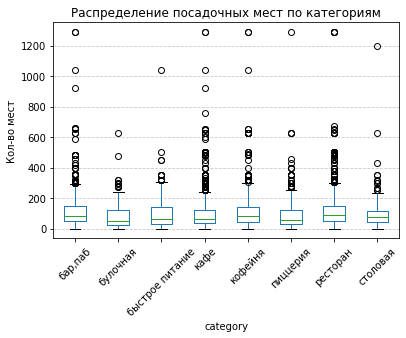

In [90]:
# Изучение разброса значений посадочных мест по категориям с фильтрацией по значению-индикатору
plt.figure(figsize=(12, 6))
filtered_seats.boxplot(column='seats', by='category', grid=False)
plt.title('Распределение посадочных мест по категориям')
plt.suptitle('')
plt.ylabel('Кол-во мест')
plt.xticks(rotation=45)

# Добавление сетки
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

В целом, значения выше пятиста, можно считать расбросом и не учитывать в гистограмме. Или технической ошибкой, например в булочной.

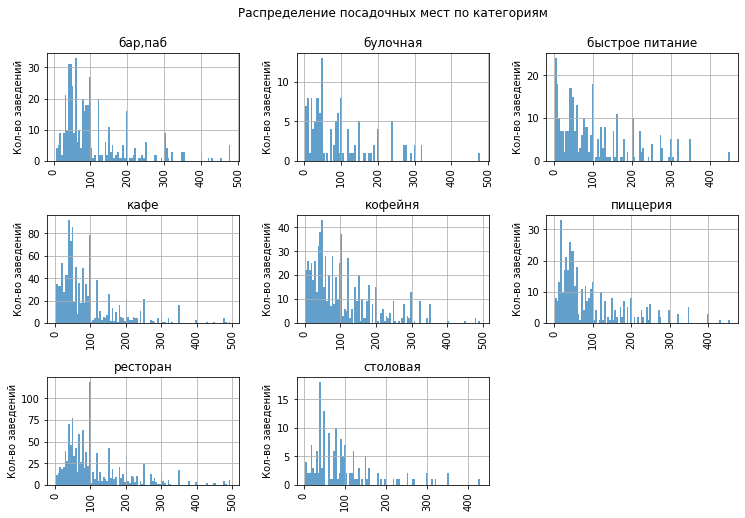

In [91]:
# Постоим гистограмму в которой отфильтруем аномальные значения
normal_seats = df[(df['seats'] > 1) & (df['seats'] < 500)]
normal_seats.hist(column='seats', by='category', bins=100, alpha=0.7, figsize=(12, 8))
plt.suptitle('Распределение посадочных мест по категориям')

# Установка подписи для оси Y
for ax in plt.gcf().axes:
    ax.set_ylabel('Кол-во заведений')

# Включение сетки
for ax in plt.gcf().axes:
    ax.grid()

plt.show()

В данных присутсвует большое количество аномалий, следовательно, медианные значения посадочных мест следует считать более корректными для каждой из категорий.

### 4.5 Анализ рейтингов заведений. 

In [92]:
# Группируем данные по категории и смотрим значения оценок

df.groupby('category')['rating'].agg(['mean', 'median', 'max', 'min','count']).sort_values(by='mean', ascending=False)

,mean,median,max,min,count
category,,,,,
"бар,паб",4.387696,4.4,5.0,1.1,764
пиццерия,4.301264,4.3,5.0,1.0,633
ресторан,4.290402,4.3,5.0,1.0,2042
кофейня,4.277282,4.3,5.0,1.4,1413
булочная,4.268359,4.3,5.0,1.3,256
столовая,4.211429,4.3,5.0,1.0,315
кафе,4.124285,4.2,5.0,1.0,2376
быстрое питание,4.050249,4.2,5.0,1.1,603


Значения среднего и медианы не сильно отличаются друг от друга, это говорит об отсутствии аномальных значений.
Самый высокий средний балл у категорий: бар&паб - `4.39` и у пиццерий `4.30`. Самый низкий средний балл у категорий: быстрое питание - `4.05` и кафе `4.12`.

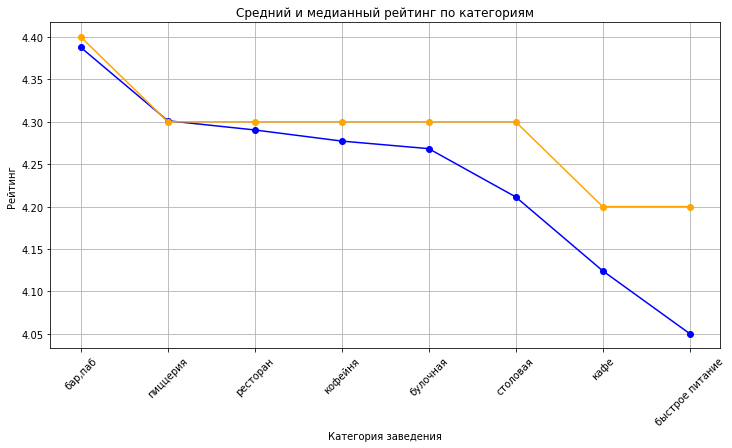

In [93]:
# Визуализация разницы

rating_stats = df.groupby('category')['rating'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

plt.figure(figsize=(12, 6))

# Построение линий для среднего и медианного рейтинга
plt.plot(rating_stats.index, rating_stats['mean'], marker='o', label='Средний рейтинг', color='blue')
plt.plot(rating_stats.index, rating_stats['median'], marker='o', label='Медианный рейтинг', color='orange')

# Настройки графика
plt.title('Средний и медианный рейтинг по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Рейтинг')
plt.xticks(rotation=45)
plt.grid()

plt.show()

Средние значения, в разных категориях, отличаются друг от друга на 0.34 балла, что говорит о близком соотношении.
Но, стоит отметить, что более однородные оценки в категориях: пиццерия и ресторан.

### 4.6 Анализ корреляции рейтингов. 

In [94]:
# Фильтруем значения индикаторы в столбцах price и seats
filtered = df[(df['price'] != -1) & (df['seats'] != -1)]

# Создаем новый df с нужными столбцами
correlation_data = filtered[['rating', 'category', 'district', 'chain', 'seats', 'price','is_24_7']]

# Удаляем NaN
correlation_data = correlation_data.dropna(subset=['price'])

# Вычисляем матрицу корреляции с помощью phik
correlation_matrix = correlation_data.phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k


,rating
price,0.320747
category,0.270397
district,0.195952
is_24_7,0.143154
chain,0.139906
seats,0.000000


Сильнее всего рейтинг зависит от местоположения 0.27 и ценовой политики заведения по 0.26 по коэффициенту phi_k. Но, обе корреляции не сильные.

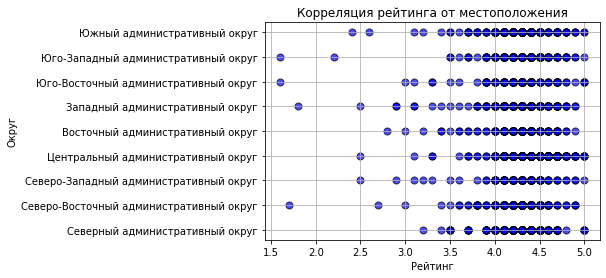

In [95]:
# Создаем диаграмму рассеяния
correlation_data.plot(
    kind='scatter',
    x='rating',
    y='district',
    alpha=0.7,
    color='blue',
    edgecolor='black',
    s=50,
    title='Корреляция рейтинга от местоположения'
)
plt.xlabel('Рейтинг')
plt.ylabel('Округ')
plt.grid()
plt.show()

Сложно сказать, что-либо интересное об этой корреляции, но в ЦАО нет оценок ниже 2.7 балла.

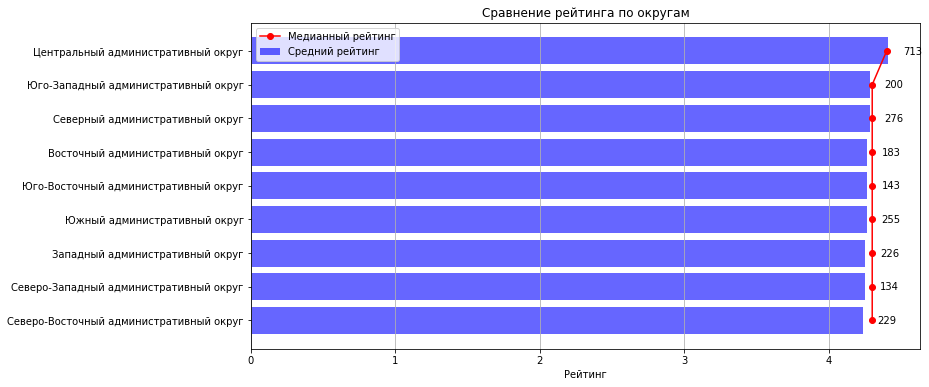

In [96]:
# Группируем данные по районам
category_grouped = correlation_data.groupby('district')['rating'].agg(['mean', 'median', 'count'])

# Сортируем по среднему рейтингу
category_grouped = category_grouped.sort_values('mean', ascending=True)

# Визуализация
plt.figure(figsize=(12, 6))

# Горизонтальная столбчатая диаграмма среднего рейтинга
plt.barh(category_grouped.index, category_grouped['mean'], color='blue', alpha=0.6, label='Средний рейтинг')

# Медиана
plt.plot(category_grouped['median'], category_grouped.index, color='red', marker='o', label='Медианный рейтинг')

# Добавим количество наблюдений
for i in range(len(category_grouped)):
    plt.text(category_grouped['mean'].iloc[i] + 0.1, i, str(category_grouped['count'].iloc[i]), va='center')

plt.title('Сравнение рейтинга по округам')
plt.xlabel('Рейтинг')
plt.legend()
plt.grid(axis='x')
plt.show()

In [97]:
# Выводим статистику
print("Статистика по округам:")
print(category_grouped.sort_values('mean', ascending=False))

Статистика по округам:
                                             mean  median  count
district                                                        
Центральный административный округ       4.412062     4.4    713
Юго-Западный административный округ      4.283000     4.3    200
Северный административный округ          4.281884     4.3    276
Восточный административный округ         4.266667     4.3    183
Юго-Восточный административный округ     4.265035     4.3    143
Южный административный округ             4.260784     4.3    255
Западный административный округ          4.253097     4.3    226
Северо-Западный административный округ   4.251493     4.3    134
Северо-Восточный административный округ  4.236245     4.3    229


Мы наблюдаем более высокие оценки в заведениях расположенных в ЦАО. Плюс ко всему, в ЦАО самая большое количкество оценок `674`.

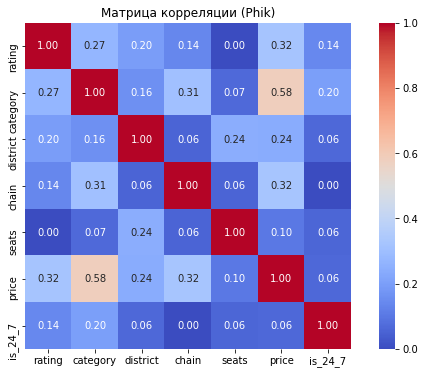

In [98]:
# Визуализируем общую матрицу корреляций по всем параметрам
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Матрица корреляции (Phik)')
plt.show()

Самый сильный уровень корреляции у столбца с ценовой политикой от столбца с категорией заведения.

### 4.7. Топ-15 популярных сетей в Москве.

In [99]:
# Группируем данные по названию заведения, считаем количество заведений в каждой сети и средний рейтинг
top = df.groupby(['name', 'category']).agg({'id': 'count', 'rating':'mean'}).sort_values(by=['id','rating'],ascending=False).reset_index() #добавляем дополнительную сортировку по рейтингу
top_15 = top.head(15)
print(top_15)

                                   name         category   id    rating
0                                  кафе             кафе  158  3.858228
1                           шоколадница          кофейня  119  4.178151
2                        домино'с пицца         пиццерия   77  4.171429
3                            додо пицца         пиццерия   74  4.286486
4                      one price coffee          кофейня   72  4.069444
5                          яндекс лавка         ресторан   69  3.872464
6                                 cofix          кофейня   65  4.075385
7                                 prime         ресторан   49  4.114286
8                              кофепорт          кофейня   42  4.147619
9   кулинарная лавка братьев караваевых             кафе   39  4.394872
10                              теремок         ресторан   36  4.105556
11                             ресторан         ресторан   33  4.315152
12                               шаурма  быстрое питание   32  3

Мы наблюдаем, сильно выраженный, топ-2 сетей по количеству заведений: Кафе - 158 и Шоколадница 119.

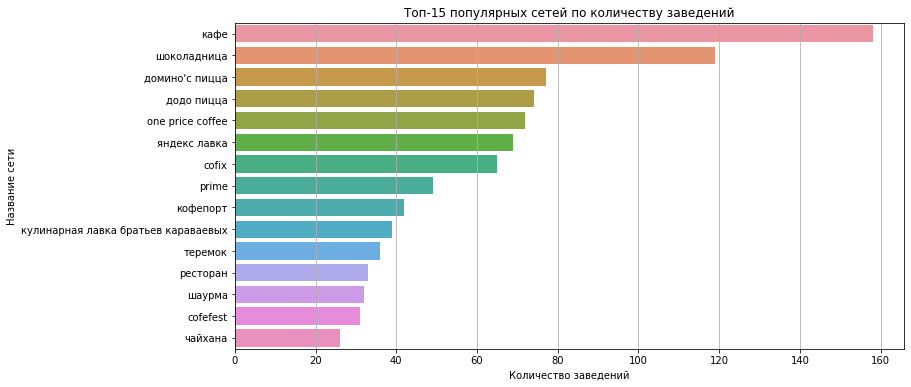

In [100]:
# Визуализация количества заведений по сетям
plt.figure(figsize=(12, 6))
sns.barplot(data=top_15, x='id', y='name')
plt.title('Топ-15 популярных сетей по количеству заведений')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.grid(axis='x')
plt.show()

In [101]:
# Группируем данные из топ-15 по категориям
top_cat = top_15.groupby('category').count().sort_values('id',ascending=False)
print(top_cat['id'])

category
кофейня            5
ресторан           4
кафе               3
пиццерия           2
быстрое питание    1
Name: id, dtype: int64


Чаще всего, в топ-15 встречаются кофейни - 5 раз.

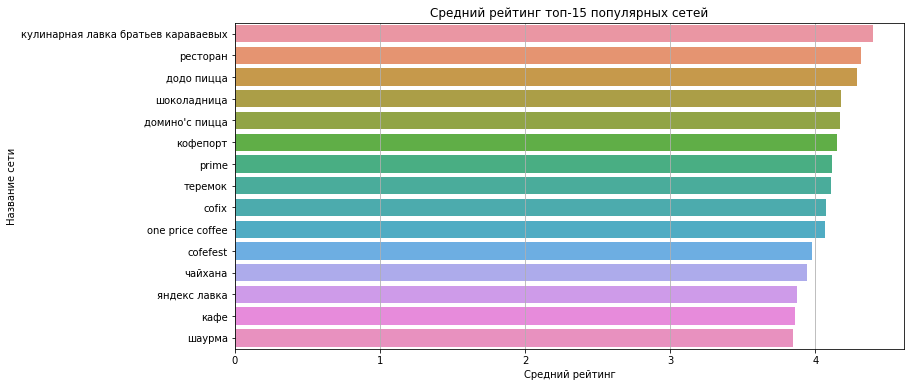

In [102]:
# Визуализация среднего рейтинга по сетям

top_rating = top_15.sort_values('rating', ascending=False) #сортируем по рейтингу

plt.figure(figsize=(12, 6))
sns.barplot(data=top_rating, x='rating', y='name')
plt.title('Средний рейтинг топ-15 популярных сетей')
plt.xlabel('Средний рейтинг')
plt.grid(axis='x')
plt.ylabel('Название сети')
plt.show()

Если рассматривать топ-15 в разрезе ретинга, то на первых местах окажуться другие заведения. Например, ресторан джонджоли имеет 4.425 средний балл или мск lounge имеет балл 4.413.


### 4.8. Анализ среднего чека заведения.

In [103]:
# Фильтруем значение-индикатор -1
df = df[df['middle_avg_bill'] > 0]

# Группируем данные по округу и формируем средний чек
mean_avg_bill = df.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)
print(mean_avg_bill)

district
Центральный административный округ         1149.303483
Западный административный округ            1005.673528
Северный административный округ             890.515587
Южный административный округ                822.464804
Северо-Западный административный округ      808.575142
Юго-Западный административный округ         788.015293
Восточный административный округ            784.614846
Северо-Восточный административный округ     701.369144
Юго-Восточный административный округ        638.435998
Name: middle_avg_bill, dtype: float64


Разница в значениях среднего чека в ЦАО - 1192Р и ЮВАО - 654Р, практически, в два раза.

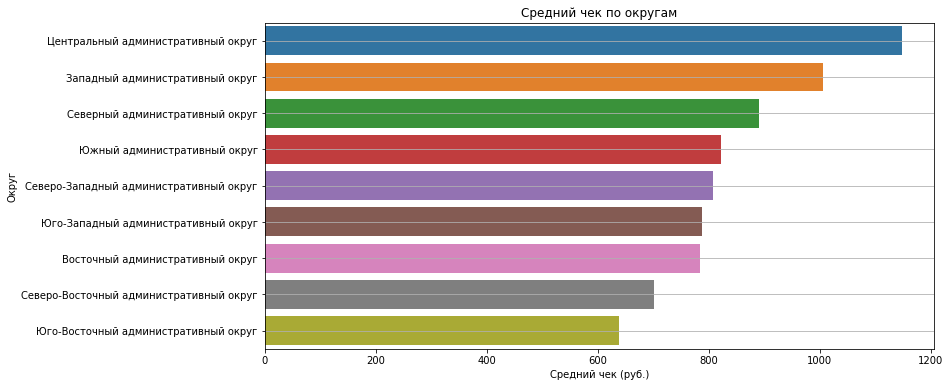

In [104]:
# Создаем df для визуализации
mean_avg_bill_df = mean_avg_bill.reset_index()

# Визуализируем данные
plt.figure(figsize=(12, 6))
sns.barplot(data=mean_avg_bill_df, x='middle_avg_bill', y='district')
plt.title('Средний чек по округам')
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Округ')
plt.grid(axis='y')
plt.show()


Удалённость от центра оказывает прямую зависимость на значние среднего чека.

## 4. Итоговые выводы

### 5.1 Общий обзор проделанной работы.

В ходе исследования были проанализированы данные сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Которые включали в себя информацию о заведениях общественного питания города Москвы. Акцент в исследовании был сделан на поиск взаимосвязей и закономерностей между категориями заведений, их ценовой политикой, местом положения, рейтигом, графиком и количеством посадочных мест.

### 5.2 Главные выводы.


#### Общая статистика
- По количеству открытых заведений в Москве лидируют категории: кафе - `2376`заведений, ресторан - `2042`заведений и кофейня `1413` заведений. Меньше всего: столовых - `182` заведений и булочных `54` заведений.

#### Об округах
- В разрезе по округам, с большим отрывом, более чем в два с половиной раза, лидирует ЦАО с `2242` заведениями. Меньше всего завдений, так-же с большим отрывом, у Северо-Западного административного округа: `409`.
- Больше всего в ЦАО - ресторанов: `670` заведений, кафе: `464` и кофейнь: `428`. Меньше всего столовых и булочных: `44` и `13` заведений.
- Практически `30%` заведений в ЦАО - это рестораны, чуть более `20%`, это кафе. Ниже порога в `5%` находятся: пиццерии, быстрое питание, столовые и булочные. Такая пропорция, скорее всего, связана с тем, что у заведений в ЦАО высокая ценовая политика, которая не свойствена заведением категории: пиццерия, быстрое питание, столовыя и булочная.

#### О принадлежности к сетям
- Сумарное количество несетевых заведений намного больше - `5258`, чем сетвых - `3144`. В разрезе категорий, пропорции выглядят так: больше всего сетевых заведений находится в категориях: ресторан, кофейня и кафе. Несетевых, больше всего: кафе и ресторанов.
- Если рассматривать отдельно сетевые заведения, то больше всего их находится в категориях: кофейня и ресторан, а имеено Кафе - `158` и Шоколадница - `119`.

#### О количестве посадочных мест
- Стоит отметить, что большая часть заведений имеет значение посадочных мест в диапозоне от `40` до `150`.

#### О рейтинге
- Средние значения, в разных категориях, отличаются друг от друга на `0.34` балла, от `4.05 до 4.39`, что говорит о близком соотношении.
Но, стоит отметить, что более однородные оценки в категориях: пиццерия и ресторан.
- Самый высокий средний балл у категорий: бар&паб - `4.39` и у пиццерий `4.30`. Самый низкий средний балл у категорий: быстрое питание - `4.05` и булочная `4.12`.
- Сильнее всего рейтинг зависит от местоположения и ценовой политики заведения, `0.27` и `0.26` по коэффициенту phi_k. Но, обе корреляции не сильные.
Самый сильный уровень корреляции у параметров связанных с ценовой политикой и с парметрами связанними с категорией заведения `0.56`.

#### О среднем чеке
- Удалённость от центра оказывает прямую зависимость на значние среднего чека. Разница в значениях среднего чека в ЦАО - `1192Р` и ЮВАО - `654Р`, практически, в два раза.

### 5.3 Рекомендации на основе анализа данных

Определённо стоит рассматривать открытие заведеня в ЦАО, категории: бар&паб, ресторан или кофейня.
Или можно рассмотреть покупку франшизы сетей, таких как: Шоколадница или Додо-пицца.